<a href="https://colab.research.google.com/github/xjx06127/Advantech_anomaly_detection/blob/main/advantech_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

sample_data


In [ ]:
!pwd

/content


In [ ]:
!ls

sample_data  training_dataset.csv


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib # 모델 저장을 위해 사용

# --- 1. 데이터 준비 (학습용) ---

# CSV 파일 로드
file_path = 'training_dataset.csv'
df = pd.read_csv(file_path)

# 사용할 4가지 변수 선택
selected_features = [
    'mean.Temperature_60',  # 환경 온도
    'mean.Humidity_60',     # 환경 습도
    'mean.hr_60',           # 심박수
    'mean.WristT_60'        # 손목 체온
]

# 4개 변수 중 하나라도 NaN (결측치)이면 해당 행 제거
df_clean = df[selected_features].dropna()

# 모델 학습을 위해 numpy 배열로 변환
X_normal_train = df_clean.values

# 스케일링 (중요): StandardScaler를 사용해 데이터를 표준화
# (참고: 나중에 새로운 데이터에도 '동일한' 스케일러를 적용해야 함)
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal_train)

print(f"총 {len(X_normal_scaled)}개의 '정상' 데이터로 학습 시작...")


# --- 2. Isolation Forest 모델 학습 및 임계값 설정 ---

# Isolation Forest 모델 초기화
# contamination=0.01 의미: 학습 데이터의 약 1%를 이상치로 간주함
model = IsolationForest(contamination=0.01, random_state=42)

# '정상' 데이터로 모델 학습
model.fit(X_normal_scaled)
print("모델 학습 완료.")

# '정상' 데이터가 받은 점수(Anomaly Score) 계산
# decision_function: 점수가 높을수록 정상, 낮을수록 이상
scores_normal = model.decision_function(X_normal_scaled)

# 임계값(Threshold) 설정:
# '정상' 데이터 점수 중 하위 1% (contamination=0.01과 일치)
threshold = np.percentile(scores_normal, 1)

print(f"이상 탐지 임계값(Threshold) 설정 완료: {threshold:.6f}")
print(f"이 값보다 낮은 점수가 나오면 '이상'으로 판단합니다.")


# --- 3. 모델 및 스케일러 저장 (필수) ---

# 학습된 모델과 스케일러를 파일로 저장
# 'scaler.joblib': 데이터를 변환하는 규칙 저장
# 'iforest_model.joblib': 이상 탐지 모델 저장
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(model, 'iforest_model.joblib')
joblib.dump(threshold, 'threshold.joblib') # 임계값도 저장

print("\n--- 모델, 스케일러, 임계값 저장 완료 ---")
print("  - scaler.joblib")
print("  - iforest_model.joblib")
print("  - threshold.joblib")


# --- 4. (참고) 실시간 탐지에 적용하는 방법 (시뮬레이션) ---

print("\n--- 실시간 탐지 시뮬레이션 시작 ---")

# (가정) 나중에 실시간 예측기가 실행될 때...
# 1. 저장된 파일들을 불러옵니다.
loaded_scaler = joblib.load('scaler.joblib')
loaded_model = joblib.load('iforest_model.joblib')
loaded_threshold = joblib.load('threshold.joblib')

# (가정) 센서에서 새로운 데이터 2건이 들어옴
# [온도, 습도, 심박수, 손목체온]
new_data_1_normal = np.array([[25.0, 50.0, 75.0, 33.0]]) # 정상적인 상황
new_data_2_abnormal = np.array([[38.0, 80.0, 150.0, 40.0]]) # (시뮬레이션) 열사병 의심 상황

# 2. '반드시' 학습 때 사용한 '그 스케일러'로 변환
new_data_1_scaled = loaded_scaler.transform(new_data_1_normal)
new_data_2_scaled = loaded_scaler.transform(new_data_2_abnormal)

# 3. 모델로 점수 계산
score_1 = loaded_model.decision_function(new_data_1_scaled)
score_2 = loaded_model.decision_function(new_data_2_scaled)

print(f"  a) 정상 데이터 점수: {score_1[0]:.6f}")
print(f"  b) 이상 데이터 점수: {score_2[0]:.6f}")

# 4. 임계값(Threshold)과 비교하여 판단
if score_1[0] < loaded_threshold:
    print("  -> a) 데이터는 '이상'입니다. (경보)")
else:
    print("  -> a) 데이터는 '정상'입니다.")

if score_2[0] < loaded_threshold:
    print("  -> b) 데이터는 '이상'입니다. (경보)")
else:
    print("  -> b) 데이터는 '정상'입니다.")

총 2441개의 '정상' 데이터로 학습 시작...
모델 학습 완료.
이상 탐지 임계값(Threshold) 설정 완료: 0.000000
이 값보다 낮은 점수가 나오면 '이상'으로 판단합니다.

--- 모델, 스케일러, 임계값 저장 완료 ---
  - scaler.joblib
  - iforest_model.joblib
  - threshold.joblib

--- 실시간 탐지 시뮬레이션 시작 ---
  a) 정상 데이터 점수: 0.110870
  b) 이상 데이터 점수: -0.097913
  -> a) 데이터는 '정상'입니다.
  -> b) 데이터는 '이상'입니다. (경보)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib # 모델 저장을 위해 사용

# --- 1. 데이터 준비 (학습용) ---

# CSV 파일 로드
file_path = 'training_dataset.csv'
df = pd.read_csv(file_path)

# 사용할 4가지 변수 선택
selected_features = [
    'mean.Temperature_60',  # 환경 온도
    'mean.Humidity_60',     # 환경 습도
    'mean.hr_60',           # 심박수
    'mean.WristT_60'        # 손목 체온
]

# 4개 변수 중 하나라도 NaN (결측치)이면 해당 행 제거
df_clean = df[selected_features].dropna()

# 모델 학습을 위해 numpy 배열로 변환
X_normal_train = df_clean.values

# 스케일링 (중요): StandardScaler를 사용해 데이터를 표준화
# (참고: 나중에 새로운 데이터에도 '동일한' 스케일러를 적용해야 함)
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal_train)

print(f"총 {len(X_normal_scaled)}개의 '정상' 데이터로 학습 시작...")


# # --- 2. Isolation Forest 모델 학습 및 임계값 설정 ---

# Isolation Forest 모델 초기화
# contamination=0.01 의미: 학습 데이터의 약 1%를 이상치로 간주함
# ramdom_state=42는 재현성을 위함. seed라고 생각. 같은 숫자면 노상관. 42는 관례
model = IsolationForest(contamination=0.01, random_state=42)

# # '정상' 데이터로 모델 학습
model.fit(X_normal_scaled)
print("모델 학습 완료.")

# '정상' 데이터가 받은 점수(Anomaly Score) 계산
# decision_function: 점수가 높을수록 정상, 낮을수록 이상
# 고립 경로의 길이를 변환
scores_normal = model.decision_function(X_normal_scaled)

# 임계값(Threshold) 설정:
# '정상' 데이터 점수 중 하위 1% (contamination=0.01과 일치)
# 점수 낮은 1% 이상치 임계값으로 보겠다는 소리
# 0으로 설정됨. 즉, 이제 음수면 이상, 양수면 정상
threshold = np.percentile(scores_normal, 1)

print(f"이상 탐지 임계값(Threshold) 설정 완료: {threshold:.6f}")
print(f"이 값보다 낮은 점수가 나오면 '이상'으로 판단합니다.")


# --- 3. 모델 및 스케일러 저장 (필수) ---

# 학습된 모델과 스케일러를 파일로 저장
# 'scaler.joblib': 데이터를 변환하는 규칙 저장
# 'iforest_model.joblib': 이상 탐지 모델 저장
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(model, 'iforest_model.joblib')
joblib.dump(threshold, 'threshold.joblib') # 임계값도 저장

print("\n--- 모델, 스케일러, 임계값 저장 완료 ---")
print("  - scaler.joblib")
print("  - iforest_model.joblib")
print("  - threshold.joblib")


# # --- 4. (참고) 실시간 탐지에 적용하는 방법 (시뮬레이션) ---

print("\n--- 실시간 탐지 시뮬레이션 시작 ---")

# (가정) 나중에 실시간 예측기가 실행될 때...
# 1. 저장된 파일들을 불러옵니다.
loaded_scaler = joblib.load('scaler.joblib')
loaded_model = joblib.load('iforest_model.joblib')
loaded_threshold = joblib.load('threshold.joblib')

# (가정) 센서에서 새로운 데이터 2건이 들어옴
# [온도, 습도, 심박수, 손목체온]
new_data_1_normal = np.array([[30.0, 50.0, 75.0, 33.0]]) # 정상적인 상황
new_data_2_abnormal = np.array([[40.0, 50.0, 75.0, 45.0]]) # (시뮬레이션) 열사병 의심 상황

# 2. '반드시' 학습 때 사용한 '그 스케일러'로 변환
new_data_1_scaled = loaded_scaler.transform(new_data_1_normal)
new_data_2_scaled = loaded_scaler.transform(new_data_2_abnormal)

# 3. 모델로 점수 계산
score_1 = loaded_model.decision_function(new_data_1_scaled)
score_2 = loaded_model.decision_function(new_data_2_scaled)

print(f"  a) 정상 데이터 점수: {score_1[0]:.6f}")
print(f"  b) 이상 데이터 점수: {score_2[0]:.6f}")

# 4. 임계값(Threshold)과 비교하여 판단
if score_1[0] < loaded_threshold:
    print("  -> a) 데이터는 '이상'입니다. (경보)")
else:
    print("  -> a) 데이터는 '정상'입니다.")

if score_2[0] < loaded_threshold:
    print("  -> b) 데이터는 '이상'입니다. (경보)")
else:
    print("  -> b) 데이터는 '정상'입니다.")

총 2441개의 '정상' 데이터로 학습 시작...
모델 학습 완료.
이상 탐지 임계값(Threshold) 설정 완료: 0.000000
이 값보다 낮은 점수가 나오면 '이상'으로 판단합니다.

--- 모델, 스케일러, 임계값 저장 완료 ---
  - scaler.joblib
  - iforest_model.joblib
  - threshold.joblib

--- 실시간 탐지 시뮬레이션 시작 ---
  a) 정상 데이터 점수: 0.062879
  b) 이상 데이터 점수: 0.000484
  -> a) 데이터는 '정상'입니다.
  -> b) 데이터는 '정상'입니다.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM # One-Class SVM 불러오기
import joblib

# --- 1. 모델 학습 및 저장 (Training and Saving) ---

file_path = 'training_dataset.csv'
df = pd.read_csv(file_path)

# 사용할 4가지 변수 선택 (이전과 동일)
selected_features = [
    'mean.Temperature_60',  # 환경 온도
    'mean.Humidity_60',     # 환경 습도
    'mean.hr_60',           # 심박수
    'mean.WristT_60'        # 손목 체온
]

# 결측치 제거 및 데이터 준비
df_clean = df[selected_features].dropna()
X_normal_train = df_clean.values

# 스케일러 학습 및 변환 (StandardScaler)
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal_train)

print(f"총 {len(X_normal_scaled)}개의 '정상' 데이터로 One-Class SVM 학습 시작...")

# One-Class SVM 모델 초기화 및 학습
# nu=0.01: Isolation Forest의 contamination과 유사한 역할 (예상 이상치 비율)
# gamma='auto': 커널 함수 설정 (일반적으로 'auto' 사용)
model_svm = OneClassSVM(nu=0.01, kernel="rbf", gamma="auto")
model_svm.fit(X_normal_scaled)
print("One-Class SVM 모델 학습 완료.")

# 임계값(Threshold) 설정
# One-Class SVM의 decision_function도 음수면 이상, 양수면 정상
scores_normal_svm = model_svm.decision_function(X_normal_scaled)
threshold_svm = np.percentile(scores_normal_svm, 1) # 하위 1% 지점의 점수

print(f"이상 탐지 임계값(Threshold) 설정 완료: {threshold_svm:.6f}")
print("==============================================")


# 모델, 스케일러, 임계값 저장 (파일명 변경)
joblib.dump(scaler, 'scaler_svm.joblib')
joblib.dump(model_svm, 'ocsvm_model.joblib')
joblib.dump(threshold_svm, 'threshold_svm.joblib')

print("\n--- One-Class SVM 모델 저장 완료 ---")


# --- 2. 단일 이상치 시뮬레이션 (검증) ---

# 저장된 파일들을 불러오기
loaded_scaler_svm = joblib.load('scaler_svm.joblib')
loaded_model_svm = joblib.load('ocsvm_model.joblib')
loaded_threshold_svm = joblib.load('threshold_svm.joblib')

# [테스트 1] 단일 이상치: 체온만 극단적으로 높은 상황 (45.0도)
# [온도, 습도, 심박수, 손목체온]
test_data_single_anomaly = np.array([[30.0, 50.0, 75.0, 37.0]])

# [테스트 2] 복합 이상치: 열사병 의심 상황 (40도, 150bpm)
test_data_compound_anomaly = np.array([[38.0, 80.0, 150.0, 37.0]])

# 스케일링
scaled_data_single = loaded_scaler_svm.transform(test_data_single_anomaly)
scaled_data_compound = loaded_scaler_svm.transform(test_data_compound_anomaly)

# 모델로 점수 계산
score_single = loaded_model_svm.decision_function(scaled_data_single)
score_compound = loaded_model_svm.decision_function(scaled_data_compound)

# 4. 임계값과 비교하여 최종 판단 함수
def check_anomaly(score, threshold):
    return "이상입니다. (경보 🚨)" if score < threshold else "정상입니다. ✅"

print("\n--- One-Class SVM 판정 결과 ---")
print(f"단일 이상치 (WristT=45.0) 예측 점수: {score_single[0]:.6f}")
print(f"판정: {check_anomaly(score_single[0], loaded_threshold_svm)}")
print("-" * 30)

print(f"복합 이상치 (WristT=40.0, HR=150) 예측 점수: {score_compound[0]:.6f}")
print(f"판정: {check_anomaly(score_compound[0], loaded_threshold_svm)}")

총 2441개의 '정상' 데이터로 One-Class SVM 학습 시작...
One-Class SVM 모델 학습 완료.
이상 탐지 임계값(Threshold) 설정 완료: -0.000134

--- One-Class SVM 모델 저장 완료 ---

--- One-Class SVM 판정 결과 ---
단일 이상치 (WristT=45.0) 예측 점수: -0.591372
판정: 이상입니다. (경보 🚨)
------------------------------
복합 이상치 (WristT=40.0, HR=150) 예측 점수: -1.565308
판정: 이상입니다. (경보 🚨)


--- 하이브리드 위험 예측 모델 ---

[파트 1: 규칙 기반 모델 (분류기)]
설명: '이상'으로 판단된 데이터가 '열사병'인지 '저체온증'인지 분류합니다.
규칙 기반 분류 함수(classify_risk_rules)가 정의되었습니다.

[파트 2: 이상 감지 모델 (Isolation Forest)]
설명: '정상' 데이터가 어떤 것인지 학습하는 AI 모델을 정의하고 훈련합니다.
'training_dataset.csv'에서 2226개의 '정상' 데이터를 로드했습니다.
데이터 스케일러(StandardScaler) 훈련 완료.
이상 감지 모델(IsolationForest) 훈련 완료.
모델 훈련 완료. 이 모델은 이제 '정상' 상태가 무엇인지 학습했습니다.

[파트 3: 하이브리드 모델 예측]
설명: (1)이상 감지 -> (2)규칙 분류의 2단계 예측을 수행합니다.

--- 3.1 예측 테스트 ---

[몸(귓볼) 온도, 심박수, 환경 온도, 환경 습도]
입력 (열사병): [[39.0, 120, 31.0, 80]] -> 예측: 열사병 위험
입력 (저체온증): [[28.0, 50, 0.0, 30]] -> 예측: 저체온증 위험
입력 (일반환경 고열): [[39.0, 110, 15.0, 50]] -> 예측: 일반환경 고열
입력 (일반환경 저열): [[28.0, 50, 15.0, 50]] -> 예측: 일반환경 저열
입력 (고온환경 일반온도): [[34.0, 70, 31.0, 80]] -> 예측: 고온환경 일반온도
입력 (저온환경 일반온도): [[34.0, 70, 0.0, 30]] -> 예측: 저온환경 일반온도
입력 (정상): [[34, 70, 15.0, 50]] -> 예측: 정상 (Normal)

--- IsolationForest 예측 점수 (0에 가까울수록 정상) ---
열사병 의심 점수: -0.1736
저체온증 의심 점수: -0.1925
일반환경 고열 의심 점수: -0.0709
일반환경 저열 의심 점수: -0.0278
고온환경 일반온도 의심 점수: -0.0681

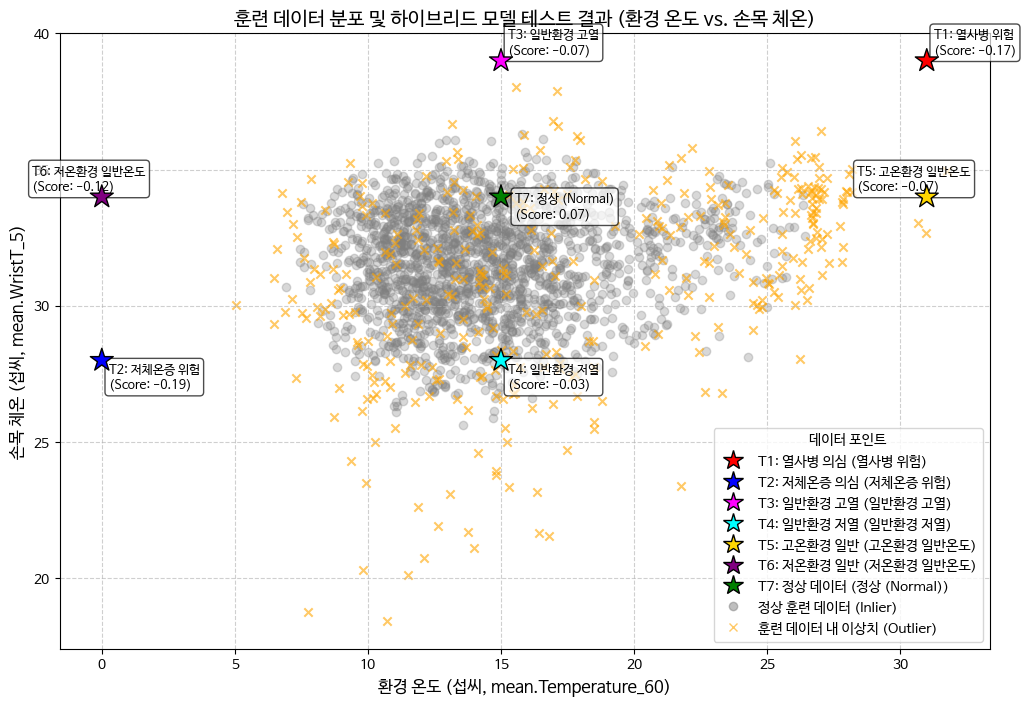

2차원 시각화 결과가 성공적으로 출력되었습니다.


In [5]:
"""
'정상' 데이터로 학습된 '이상 감지 모델'과
'열사병/저체온증'을 분류하는 '규칙 기반 모델'을 결합
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt # 시각화를 위한 라이브러리 추가
from matplotlib.lines import Line2D

# 한글 폰트 설정 (Colab 환경에서 한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

print("--- 하이브리드 위험 예측 모델 ---")

# =============================================================================
# 파트 1: 규칙 기반 모델 (분류기)
# =============================================================================
print("\n[파트 1: 규칙 기반 모델 (분류기)]")
print("설명: '이상'으로 판단된 데이터가 '열사병'인지 '저체온증'인지 분류합니다.")

# 체감온도 표 데이터 (기온: {습도: 체감온도})
# 표에 있는 25°C ~ 40°C 및 25% ~ 100% 데이터 전체를 포함합니다.
WIND_CHILL_DATA = {
    25: {25: 22.2, 30: 22.8, 35: 23.3, 40: 23.8, 45: 24.2, 50: 24.6, 55: 25.1, 60: 25.5, 65: 25.9, 70: 26.2, 75: 26.6, 80: 27.0, 85: 27.3, 90: 27.7, 95: 28.0, 100: 28.4},
    26: {25: 23.1, 30: 23.7, 35: 24.2, 40: 24.7, 45: 25.2, 50: 25.6, 55: 26.0, 60: 26.5, 65: 26.9, 70: 27.2, 75: 27.6, 80: 28.0, 85: 28.4, 90: 28.7, 95: 29.1, 100: 29.4},
    27: {25: 24.0, 30: 24.6, 35: 25.2, 40: 25.7, 45: 26.1, 50: 26.6, 55: 27.0, 60: 27.5, 65: 27.9, 70: 28.2, 75: 28.6, 80: 29.0, 85: 29.4, 90: 29.7, 95: 30.1, 100: 30.5},
    28: {25: 24.9, 30: 25.5, 35: 26.1, 40: 26.6, 45: 27.0, 50: 27.5, 55: 28.0, 60: 28.4, 65: 28.9, 70: 29.3, 75: 29.7, 80: 30.0, 85: 30.4, 90: 30.8, 95: 31.1, 100: 31.5},
    29: {25: 25.8, 30: 26.5, 35: 27.0, 40: 27.6, 45: 28.1, 50: 28.6, 55: 29.0, 60: 29.4, 65: 29.9, 70: 30.3, 75: 30.7, 80: 31.1, 85: 31.4, 90: 31.8, 95: 32.2, 100: 32.6},
    30: {25: 26.7, 30: 27.4, 35: 28.0, 40: 28.5, 45: 29.0, 50: 29.5, 55: 30.0, 60: 30.4, 65: 30.9, 70: 31.3, 75: 31.7, 80: 32.1, 85: 32.5, 90: 32.9, 95: 33.2, 100: 33.6},
    31: {25: 27.6, 30: 28.3, 35: 28.9, 40: 29.4, 45: 30.0, 50: 30.5, 55: 31.0, 60: 31.4, 65: 31.9, 70: 32.3, 75: 32.7, 80: 33.1, 85: 33.5, 90: 33.9, 95: 34.3, 100: 34.6},
    32: {25: 28.5, 30: 29.2, 35: 29.8, 40: 30.4, 45: 31.0, 50: 31.5, 55: 32.0, 60: 32.4, 65: 32.9, 70: 33.3, 75: 33.7, 80: 34.1, 85: 34.5, 90: 34.9, 95: 35.3, 100: 35.7},
    33: {25: 29.5, 30: 30.2, 35: 30.8, 40: 31.4, 45: 32.0, 50: 32.5, 55: 33.0, 60: 33.5, 65: 33.9, 70: 34.3, 75: 34.8, 80: 35.2, 85: 35.6, 90: 36.0, 95: 36.4, 100: 36.7},
    34: {25: 30.4, 30: 31.1, 35: 31.8, 40: 32.4, 45: 32.9, 50: 33.5, 55: 34.0, 60: 34.5, 65: 34.9, 70: 35.4, 75: 35.8, 80: 36.2, 85: 36.6, 90: 37.0, 95: 37.4, 100: 37.8},
    35: {25: 31.3, 30: 32.0, 35: 32.7, 40: 33.3, 45: 33.9, 50: 34.5, 55: 35.0, 60: 35.5, 65: 35.9, 70: 36.4, 75: 36.8, 80: 37.2, 85: 37.7, 90: 38.1, 95: 38.5, 100: 38.9},
    36: {25: 32.2, 30: 33.0, 35: 33.7, 40: 34.3, 45: 34.9, 50: 35.4, 55: 36.0, 60: 36.5, 65: 36.9, 70: 37.4, 75: 37.8, 80: 38.3, 85: 38.7, 90: 39.1, 95: 39.5, 100: 40.0},
    37: {25: 33.1, 30: 33.9, 35: 34.6, 40: 35.3, 45: 35.9, 50: 36.4, 55: 37.0, 60: 37.5, 65: 38.0, 70: 38.4, 75: 38.9, 80: 39.3, 85: 39.7, 90: 40.2, 95: 40.6, 100: 41.0},
    38: {25: 34.0, 30: 34.8, 35: 35.6, 40: 36.2, 45: 36.9, 50: 37.4, 55: 38.0, 60: 38.5, 65: 39.0, 70: 39.5, 75: 39.9, 80: 40.4, 85: 40.8, 90: 41.2, 95: 41.6, 100: 42.0},
    39: {25: 35.0, 30: 35.8, 35: 36.5, 40: 37.2, 45: 37.8, 50: 38.4, 55: 39.0, 60: 39.5, 65: 40.0, 70: 40.5, 75: 40.9, 80: 41.4, 85: 41.8, 90: 42.3, 95: 42.7, 100: 43.1},
    40: {25: 35.9, 30: 36.7, 35: 37.5, 40: 38.2, 45: 38.8, 50: 39.4, 55: 40.0, 60: 40.5, 65: 41.0, 70: 41.5, 75: 42.0, 80: 42.4, 85: 42.8, 90: 43.3, 95: 43.7, 100: 44.1}
}

def get_wind_chill(env_temp, env_humidity):
    """
    제공된 표에서 기온과 습도에 해당하는 체감온도를 조회합니다.
    기온은 가장 가까운 정수로, 습도는 가장 가까운 5의 배수로 반올림하여 근사값을 찾습니다.
    """
    # 1. 기온 (env_temp)을 가장 가까운 정수로 반올림
    rounded_temp = int(round(env_temp))

    # 2. 기온 경계값 (25°C 미만, 40°C 초과) 처리
    if rounded_temp < 25 or rounded_temp > 40:
        return None  # 표 데이터 범위를 벗어남

    temp_data = WIND_CHILL_DATA[rounded_temp]

    # 3. 습도 (env_humidity)를 가장 가까운 5의 배수로 반올림
    rounded_humidity = int(round(env_humidity / 5.0) * 5)

    # 4. 습도 경계값 (25% 미만, 100% 초과) 처리
    if rounded_humidity < 25:
        return None;
    if rounded_humidity > 100:
        return None;

    # 5. 조회된 습도값이 데이터에 있는지 확인 및 체감온도 반환
    if rounded_humidity in temp_data:
        return temp_data[rounded_humidity]
    else:
        return None

def classify_risk_rules(body_temp, heart_rate, env_temp, env_humidity):
    """
    규칙 기반으로 위험 상태를 분류하는 함수.
    고온 환경 기준은 기온(env_temp)과 습도(env_humidity)로 계산된 체감온도를 사용합니다.
    """
    # 1. 체감온도 계산 또는 조회
    wind_chill = get_wind_chill(env_temp, env_humidity)

    # 표에 없는 온도/습도 조합일 경우 기존 env_temp 기준을 사용
    if wind_chill is None:
        effective_env_temp = env_temp
    else:
        effective_env_temp = wind_chill

# 임계값 정의
# 일사병 심부체온 37~40도
# 열사병 심부체온 40도 이상

# 저체온증 심부체온 35도 이하

# 체감온도 31도 이상
# >> 온열질환 예방조치 해야하는 환경
# https://www.kosha.or.kr/kosha/business/heatWaveTemperature.do
# >> 그냥 환경온도 31도로 잡자

# 한랭작업환경
# >> 등가냉각온도 측정해야함(풍량)
# >> 4도 이하면 보호구 착용해야하니까 4도 기준으로 하자
# W-17-2015 한랭작업환경 관리지침.pdf

    HIGH_ENV_TEMP = 31.0  # 고온 환경 기준 (섭씨)
    LOW_ENV_TEMP = 4.0   # 저온 환경 기준 (섭씨)
    HIGH_WRIST_TEMP_DANGER = 35.0 # 고체온 위험 기준(대충 -2도 정도 했음)
    LOW_WRIST_TEMP_DANGER = 33.0  # 저체온 위험 기준(대충 -2도 정도 했음)

    # 규칙 기반 분류(case 4개)
    # 고온환경 고열, 저온환경 저열, 일반환경 고/저열, 고/저온환경 일반온도, 이상
    if effective_env_temp >= HIGH_ENV_TEMP and body_temp >= HIGH_WRIST_TEMP_DANGER:
        return "열사병 위험"
    elif env_temp <= LOW_ENV_TEMP and body_temp <= LOW_WRIST_TEMP_DANGER:
        return "저체온증 위험"
    elif body_temp >= HIGH_WRIST_TEMP_DANGER:
      return "일반환경 고열"
    elif body_temp <= LOW_WRIST_TEMP_DANGER:
      return "일반환경 저열"
    elif effective_env_temp >= HIGH_ENV_TEMP:
      return "고온환경 일반온도"
    elif env_temp <= LOW_ENV_TEMP:
      return "저온환경 일반온도"
    else:
      return "원인 불명 이상치"

print("규칙 기반 분류 함수(classify_risk_rules)가 정의되었습니다.")


# =============================================================================
# 파트 2: 이상 감지 모델 (Anomaly Detection Model)
# =============================================================================
print("\n[파트 2: 이상 감지 모델 (Isolation Forest)]")
print("설명: '정상' 데이터가 어떤 것인지 학습하는 AI 모델을 정의하고 훈련합니다.")

# --- 2.1 '정상' 데이터 준비 ---
# training_dataset.csv 파일을 로드하여 학습 데이터로 사용합니다.
df = pd.read_csv('training_dataset.csv')
X_normal = df[['mean.WristT_5', 'mean.hr_5', 'mean.Temperature_60', 'mean.Humidity_60']]
X_normal = X_normal.dropna()
X_normal.columns = ['body_temp', 'heart_rate', 'env_temp', 'env_humidity']
print(f"'training_dataset.csv'에서 {len(X_normal)}개의 '정상' 데이터를 로드했습니다.")

if X_normal.empty:
    print("경고: CSV 파일에서 유효한 데이터를 찾을 수 없습니다.")


# --- 2.2 모델 및 스케일러 정의 및 훈련 ---
# 1. 스케일러 (Scaler) 정의 및 훈련
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
print("데이터 스케일러(StandardScaler) 훈련 완료.")

# 2. 이상 감지 모델 (IsolationForest) 정의 및 훈련
model = IsolationForest(contamination='auto', random_state=42)
model.fit(X_normal_scaled)
print("이상 감지 모델(IsolationForest) 훈련 완료.")

print("모델 훈련 완료. 이 모델은 이제 '정상' 상태가 무엇인지 학습했습니다.")


# =============================================================================
# 파트 3: 하이브리드 모델 예측
# =============================================================================
print("\n[파트 3: 하이브리드 모델 예측]")
print("설명: (1)이상 감지 -> (2)규칙 분류의 2단계 예측을 수행합니다.")

def predict_hybrid(data_list, fitted_scaler, fitted_model):
    """
    하이브리드 모델 예측 함수 (Pipeline 미사용)
    1. '정상'/'이상' 판단
    2. '이상'일 경우, 종류 분류
    """
    results = []

    # 데이터를 DataFrame으로 변환
    df_data = pd.DataFrame(data_list, columns=['body_temp', 'heart_rate', 'env_temp', 'env_humidity'])

    # 1. (1단계) 학습된 스케일러로 새 데이터 변환
    data_scaled = fitted_scaler.transform(df_data)

    # 2. (1단계) 학습된 모델로 '정상'/'이상' 예측 (1 = 정상, -1 = 이상)
    anomaly_predictions = fitted_model.predict(data_scaled)

    for i in range(len(df_data)):
        if anomaly_predictions[i] == 1:
            # 1단계: 모델이 "정상"으로 판단
            results.append("정상 (Normal)")
        else:
            # 1단계: 모델이 "이상"으로 판단
            # 2단계: 규칙 기반 모델로 어떤 이상 징후인지 분류
            row = df_data.iloc[i]
            rule_result = classify_risk_rules(row['body_temp'], row['heart_rate'], row['env_temp'], row['env_humidity'])
            results.append(rule_result)

    return results

# --- 3.1 예측 테스트 ---
print("\n--- 3.1 예측 테스트 ---")
print("\n[몸(귓볼) 온도, 심박수, 환경 온도, 환경 습도]")
test_data_heat =  [[39.0, 120,  31.0, 80]] # 온열질환 의심
test_data_cold =  [[28.0, 50,  0.0,  30]] # 한랭질환 의심
test_data_1 = [[39.0, 110,  15.0, 50]] # 일반환경 고열
test_data_2 = [[28.0, 50,  15.0, 50]] # 일반환경 저열
test_data_3 = [[34.0, 70,  31.0, 80]] # 고온환경 일반온도
test_data_4 = [[34.0, 70,  0.0, 30]] # 저온환경 일반온도
test_data_normal = [[34, 70,  15.0, 50]] # 정상

all_test_data = test_data_heat + test_data_cold + test_data_1 + test_data_2 + test_data_3 + test_data_4 + test_data_normal

# 예측 함수 호출 시, 학습된 scaler와 model을 전달합니다.
predictions = predict_hybrid(all_test_data, scaler, model)

print(f"입력 (열사병): {test_data_heat} -> 예측: {predictions[0]}")
print(f"입력 (저체온증): {test_data_cold} -> 예측: {predictions[1]}")
print(f"입력 (일반환경 고열): {test_data_1} -> 예측: {predictions[2]}")
print(f"입력 (일반환경 저열): {test_data_2} -> 예측: {predictions[3]}")
print(f"입력 (고온환경 일반온도): {test_data_3} -> 예측: {predictions[4]}")
print(f"입력 (저온환경 일반온도): {test_data_4} -> 예측: {predictions[5]}")
print(f"입력 (정상): {test_data_normal} -> 예측: {predictions[6]}")

# --- 예측 점수 확인 (분석용) ---
df_data_test = pd.DataFrame(all_test_data, columns=['body_temp', 'heart_rate', 'env_temp', 'env_humidity'])
data_scaled_test = scaler.transform(df_data_test)
anomaly_scores = model.decision_function(data_scaled_test)

test_labels_short = [
    "T1: 열사병 의심",
    "T2: 저체온증 의심",
    "T3: 일반환경 고열",
    "T4: 일반환경 저열",
    "T5: 고온환경 일반",
    "T6: 저온환경 일반",
    "T7: 정상 데이터"
]

print("\n--- IsolationForest 예측 점수 (0에 가까울수록 정상) ---")
print(f"열사병 의심 점수: {anomaly_scores[0]:.4f}")
print(f"저체온증 의심 점수: {anomaly_scores[1]:.4f}")
print(f"일반환경 고열 의심 점수: {anomaly_scores[2]:.4f}")
print(f"일반환경 저열 의심 점수: {anomaly_scores[3]:.4f}")
print(f"고온환경 일반온도 의심 점수: {anomaly_scores[4]:.4f}")
print(f"저온환경 일반온도 의심 점수: {anomaly_scores[5]:.4f}")
print(f"정상 의심 점수: {anomaly_scores[6]:.4f}")

print("\n--- 코드 실행 완료 ---")
# =============================================================================
print("\n[파트 4: 2차원 시각화]")

# 1. X_normal (Training Data) Visualization: Predict the anomaly status for the training data itself
X_normal_scaled = scaler.transform(X_normal)
X_normal['Anomaly'] = model.predict(X_normal_scaled)
X_normal['Type'] = np.where(X_normal['Anomaly'] == 1, '정상 훈련 데이터', '훈련 데이터 내 이상치')

# 2. df_data_test (Test Data) Visualization: Add final prediction labels
df_data_test['Type'] = predictions
df_data_test['Anomaly Score'] = anomaly_scores

# 3. Create Scatter Plot: Environment Temp (X) vs. Body Temp (Y)
plt.figure(figsize=(12, 8)) # 가독성을 위해 크기 12x8로 설정

# Plot 1: Normal Training Data (배경 분포)
X_normal_inlier = X_normal[X_normal['Anomaly'] == 1]
X_normal_outlier = X_normal[X_normal['Anomaly'] == -1]

# 정상으로 판단된 훈련 데이터 (회색 점)
plt.scatter(
    X_normal_inlier['env_temp'],
    X_normal_inlier['body_temp'],
    c='gray',
    marker='o',
    alpha=0.3,
    label='정상 훈련 데이터 분포 (Inlier)'
)

# 훈련 데이터 내 이상치 (주황색 X)
plt.scatter(
    X_normal_outlier['env_temp'],
    X_normal_outlier['body_temp'],
    c='orange',
    marker='x',
    alpha=0.6,
    label='훈련 데이터 내 이상치 (Outlier)'
)

# Plot 2: Test Data Points (큰 별 모양)
# T1~T8에 대응하는 8가지 색상 목록
colors = ['red', 'blue', 'magenta', 'cyan', 'gold', 'purple', 'green', 'black']

plt.scatter(
    df_data_test['env_temp'],
    df_data_test['body_temp'],
    c=colors[:len(df_data_test)], # 실제 테스트 데이터 개수만큼 색상 사용
    marker='*',
    s=300, # 마커 크기
    edgecolors='black',
    zorder=5
)

# Annotate Test Data Points (점수와 예측 결과 주석 표시)
for i, row in df_data_test.iterrows():
    # T1, T2, T3... 레이블과 예측 결과, 점수를 주석으로 표시
    label_text = f"{test_labels_short[i].split(':')[0]}: {row['Type']}\n(Score: {row['Anomaly Score']:.2f})"

    # 주석 위치 조정 (8개의 포인트가 겹치지 않도록 세분화)
    if i == 0 or i == 2: # T1(열사병), T3(일반환경 고열) -> 고체온 쪽
        x_offset, y_offset = (5, 5)
    elif i == 1 or i == 3: # T2(저체온증), T4(일반환경 저열) -> 저체온 쪽
        x_offset, y_offset = (5, -20)
    elif i == 4 or i == 5: # T5(고온환경 일반), T6(저온환경 일반) -> 환경 온도 극단
        x_offset, y_offset = (-50, 5)
    else: # T7, T8 (정상 및 복사)
        # T7(Green), T8(Black)은 겹치므로 주석 위치를 분리
        if i == 6:
             x_offset, y_offset = (10, -15) # T7 주석

    plt.annotate(
        label_text,
        (row['env_temp'], row['body_temp']),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )

# Add Labels and Title
plt.title('훈련 데이터 분포 및 하이브리드 모델 테스트 결과 (환경 온도 vs. 손목 체온)', fontsize=14)
plt.xlabel('환경 온도 (섭씨, mean.Temperature_60)', fontsize=12)
plt.ylabel('손목 체온 (섭씨, mean.WristT_5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Custom Legend
legend_elements = []
for i in range(len(df_data_test)):
    # 테스트 레이블 생성: T[i+1]: (규칙 분류 결과)
    legend_elements.append(
        Line2D([0], [0], marker='*', color='w', label=f'{test_labels_short[i]} ({df_data_test.loc[i, "Type"]})',
                   markerfacecolor=colors[i], markersize=15, markeredgecolor='black')
    )

# 일반/이상 훈련 데이터 범례 추가
legend_elements.append(Line2D([0], [0], marker='o', color='gray', label='정상 훈련 데이터 (Inlier)', alpha=0.5, linestyle='None'))
legend_elements.append(Line2D([0], [0], marker='x', color='orange', label='훈련 데이터 내 이상치 (Outlier)', alpha=0.6, linestyle='None'))

plt.legend(handles=legend_elements, loc='best', title='데이터 포인트')

# 그래프 표시
plt.show()
print("2차원 시각화 결과가 성공적으로 출력되었습니다.")

In [11]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

^C
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache direc